In [2]:
!pip install shap dice-ml

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import dice_ml

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [6]:
data = pd.read_csv("heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [12]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.9414634146341463
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       100
           1       0.92      0.97      0.94       105

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205



In [14]:
#part A - SHAP 
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [16]:
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (205, 13, 2)


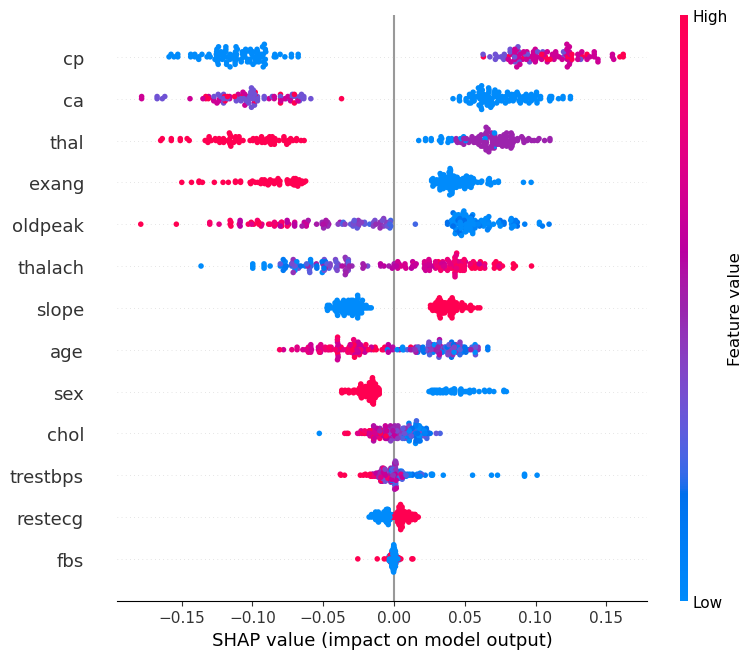

In [18]:
shap.summary_plot(shap_values[:, :, 1], X_test)

In [69]:
idx = 0
instance = X_test.iloc[idx]
instance_df = X_test.iloc[[idx]]

print("Chosen test instance:")
print(instance)

print("\nPredicted class:", model.predict(instance_df)[0])
print("Predicted probability for class 1:", model.predict_proba(instance_df)[0][1])

Chosen test instance:
age          64.0
sex           1.0
cp            0.0
trestbps    120.0
chol        246.0
fbs           0.0
restecg       0.0
thalach      96.0
exang         1.0
oldpeak       2.2
slope         0.0
ca            1.0
thal          2.0
Name: 756, dtype: float64

Predicted class: 0
Predicted probability for class 1: 0.055798306859372114


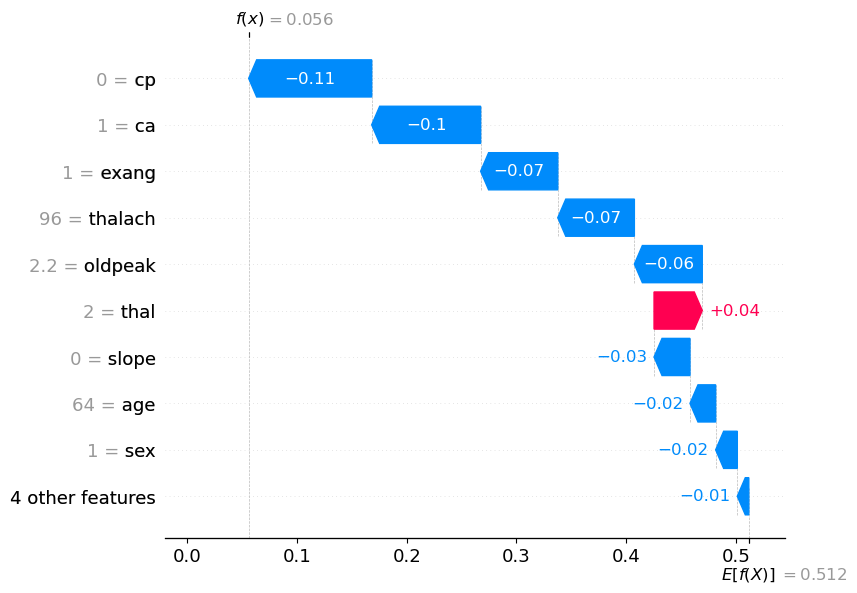

In [71]:
sample_shap = shap_values[idx][:, 1]
base_value = explainer.expected_value[1]

exp = shap.Explanation(
    values=sample_shap,
    base_values=base_value,
    data=instance.values,
    feature_names=X_test.columns
)

shap.plots.waterfall(exp)

In [73]:
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "shap_value": sample_shap
})

feature_importance["abs_shap"] = feature_importance["shap_value"].abs()
feature_importance = feature_importance.sort_values("abs_shap", ascending=False)

print("Top 5 most important features for this prediction:")
print(feature_importance.head(5))

Top 5 most important features for this prediction:
    feature  shap_value  abs_shap
2        cp   -0.112162  0.112162
11       ca   -0.099329  0.099329
8     exang   -0.070339  0.070339
7   thalach   -0.069848  0.069848
9   oldpeak   -0.061915  0.061915


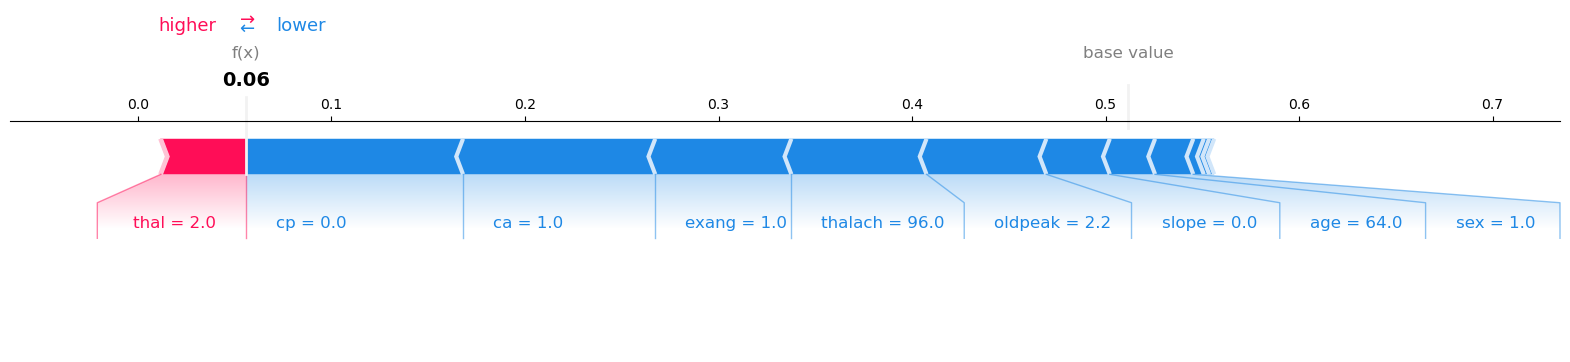

In [67]:
shap.force_plot(
    base_value,
    sample_shap,
    instance.values,
    feature_names=X_test.columns,
    matplotlib=True
)
plt.show()

In [77]:
print("Text explanation:")
for _, row in feature_importance.head(3).iterrows():
    direction = "increased" if row["shap_value"] > 0 else "decreased"
    print(f"- {row['feature']} {direction} the predicted risk of heart disease.")

Text explanation:
- cp decreased the predicted risk of heart disease.
- ca decreased the predicted risk of heart disease.
- exang decreased the predicted risk of heart disease.


In [79]:
#part B - Counterfactual explanations
train_data = X_train.copy()
train_data["target"] = y_train.values

In [81]:
continuous_features = list(X.columns)
print(continuous_features)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [83]:
d = dice_ml.Data(
    dataframe=train_data,
    continuous_features=continuous_features,
    outcome_name="target"
)

m = dice_ml.Model(
    model=model,
    backend="sklearn"
)

exp_dice = dice_ml.Dice(d, m, method="random")

In [85]:
query_instance = X_test.iloc[[idx]]

counterfactuals = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=2,
    desired_class="opposite"
)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  4.37it/s]


In [87]:
counterfactuals.visualize_as_dataframe()

Query instance (original outcome : 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,64,1,0,120,246,0,0,96,1,2.2,0,1,2,0



Diverse Counterfactual set (new outcome: 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,64,1,0,94,246,0,0,196,1,2.2,0,0,2,1
1,39,1,1,120,246,0,0,184,1,2.2,0,1,2,1


In [89]:
cf_df = counterfactuals.cf_examples_list[0].final_cfs_df
print(cf_df)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   64    1   0        94   246    0        0      196      1      2.2      0   
1   39    1   1       120   246    0        0      184      1      2.2      0   

   ca  thal  target  
0   0     2       1  
1   1     2       1  


In [91]:
original_df = query_instance.reset_index(drop=True)
first_cf = cf_df.iloc[[0]].drop(columns=["target"], errors="ignore").reset_index(drop=True)

comparison = pd.concat([original_df, first_cf], keys=["original", "counterfactual"])
print(comparison)

                  age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
original       0   64    1   0       120   246    0        0       96      1   
counterfactual 0   64    1   0        94   246    0        0      196      1   

                  oldpeak  slope  ca  thal  
original       0      2.2      0   1     2  
counterfactual 0      2.2      0   0     2  


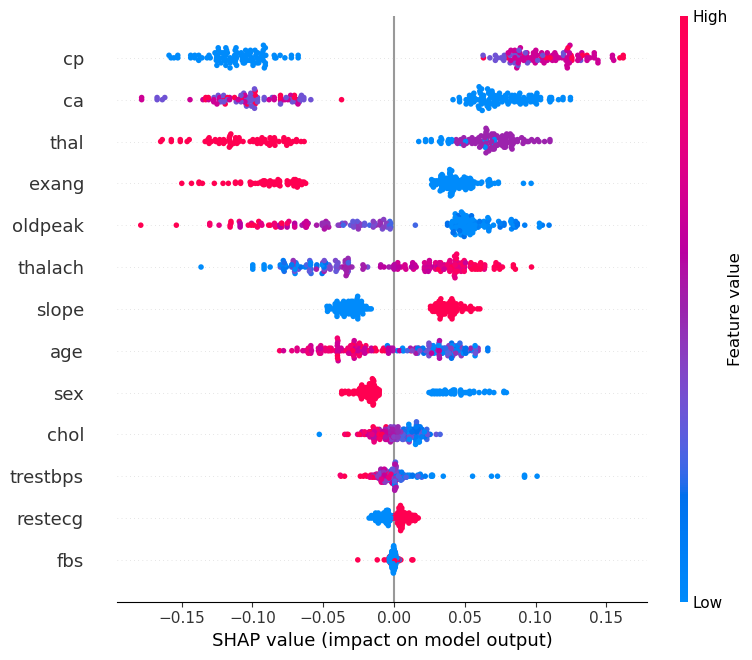

In [95]:
plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

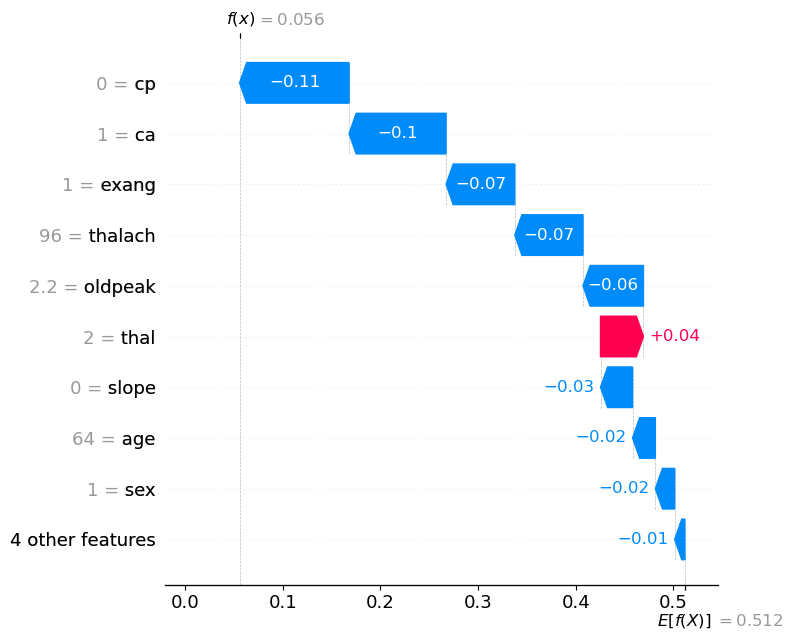

In [97]:
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
changes = []
for col in original_df.columns:
    orig_val = original_df.iloc[0][col]
    cf_val = first_cf.iloc[0][col]
    if orig_val != cf_val:
        changes.append((col, orig_val, cf_val))

print("Changes needed to flip the prediction:")
for col, orig, cf in changes:
    print(f"- {col}: {orig} -> {cf}")

Changes needed to flip the prediction:
- trestbps: 120.0 -> 94.0
- thalach: 96.0 -> 196.0
- ca: 1.0 -> 0.0


In [101]:
print("Final comparison of explanation methods")
print("\nSHAP:")
print("- Shows which features contributed most to the prediction.")
print("- Useful for local and global feature importance.")
print("- Best for understanding why the model made a decision.")

print("\nCounterfactual explanations:")
print("- Show what feature changes would lead to the opposite prediction.")
print("- More actionable and contrastive.")
print("- Useful for interactive explanation and user understanding.")

Final comparison of explanation methods

SHAP:
- Shows which features contributed most to the prediction.
- Useful for local and global feature importance.
- Best for understanding why the model made a decision.

Counterfactual explanations:
- Show what feature changes would lead to the opposite prediction.
- More actionable and contrastive.
- Useful for interactive explanation and user understanding.


In [103]:
print("Limitations of this code demo:")
print("- Counterfactual examples may not always be realistic or medically plausible.")
print("- Some features are categorical, but here they were treated as continuous for simplicity.")
print("- This demo compares explanation formats qualitatively and does not include a real user study.")

Limitations of this code demo:
- Counterfactual examples may not always be realistic or medically plausible.
- Some features are categorical, but here they were treated as continuous for simplicity.
- This demo compares explanation formats qualitatively and does not include a real user study.
